In [ ]:
# Malaria Detection with YOLOv10

# This Kaggle notebook trains a YOLOv10 model for detecting malaria-infected cells in images using a dataset from Roboflow.
# It includes:
# - Downloading the dataset in YOLO format via Roboflow API
# - Training YOLOv10 for object detection
# - Evaluating performance on the test set
# - Visualizing predictions with bounding boxes

# Requirements:
# - Enable GPU in Kaggle notebook settings (Settings > Accelerator > GPU).
# - Replace Roboflow API key, workspace, project, and version below.
# - Internet must be enabled (Settings > Internet > On).



In [ ]:
# Install dependencies
!pip install roboflow ultralytics opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 78.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:

# Verify installations
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")  # Should be >=8.2.0 for YOLOv10

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics version: 8.3.227


In [ ]:
# Import libraries
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from roboflow import Roboflow
from ultralytics import YOLO
from scipy.stats import entropy  # For advanced UQ (optional)

# Check GPU (essential for training speed)
print("GPU Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

GPU Available: True
GPU Name: Tesla T4


In [ ]:
# Import libraries
import os
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np
from pathlib import Path


In [ ]:
# Check GPU
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [ ]:
# !pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="LTr5HLE3dWVjkbNU998P")
# project = rf.workspace("malariaproject-cfxol").project("testuploads")
# version = project.version(1)
# dataset = version.download("yolov8")
!pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="LTr5HLE3dWVjkbNU998P")
# project = rf.workspace("malariaproject-cfxol").project("journal-paper-experiment-1")
# version = project.version(2)
# dataset = version.download("yolov8")


# Download your malaria dataset (replace with your actual details if needed)
rf = Roboflow(api_key="LTr5HLE3dWVjkbNU998P")  # Your API key
project = rf.workspace("malariaproject-cfxol").project("journal-paper-experiment-1")
version = project.version(1)
dataset = version.download("yolov8")  # YOLOv8 format works for YOLOv10

# Define paths
dataset_path = dataset.location
data_yaml = os.path.join(dataset_path, "data.yaml")

# Verify dataset (your 5 classes: pv, po, pf, pm, wbc)
print("Dataset Structure:")
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_path, split, 'images')
    label_dir = os.path.join(dataset_path, split, 'labels')
    if os.path.exists(img_dir):
        num_imgs = len(os.listdir(img_dir))
        print(f"{split}: {num_imgs} images, {len(os.listdir(label_dir))} labels")

# Show classes from data.yaml
with open(data_yaml, 'r') as f:
    content = f.read()
    print("\nClasses in data.yaml:")
    print([line.split(':')[0].strip() for line in content.split('\n') if 'names:' in content and line.strip().startswith('  ')])


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to journal-paper-experiment-1-1 in yolov8:: 100%|██████████| 5070/5070 [00:00<00:00, 9023.48it/s]

Dataset Structure:
train: 1771 images, 1771 labels
valid: 506 images, 506 labels
test: 252 images, 252 labels

Classes in data.yaml:
[]


In [ ]:
# Load pre-trained YOLOv10 small model (good balance of speed/accuracy for cells)
model = YOLO('yolov10s.pt')  # Downloads if needed

# Train (tuned for medical images: lower LR, more patience)
results = model.train(
    data=data_yaml,
    epochs=20,
    imgsz=640,  # Image size; cells are small, so 640px works
    batch=16,   # Adjust if GPU OOM (out of memory)
    device=0,   # GPU
    name='malaria_yolov10_uq',
    project='/kaggle/working/runs',
    patience=15,  # Stop early if no improvement
    pretrained=True,
    optimizer='AdamW',  # Better than SGD for fine-tuning
    lr0=0.001,   # Lower learning rate for stability
    dropout=0.1  # Explicitly set dropout rate (helps MC Dropout later)
)

print("Training completed! Best model saved in /kaggle/working/runs/detect/malaria_yolov10_uq/weights/best.pt")

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/journal-paper-experiment-1-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=malaria_yolov10_uq, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=15, pers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ls

input/  working/


In [ ]:
# Load trained model
model = YOLO('/kaggle/working/runs/malaria_yolov10_uq/weights/best.pt')
# /kaggle/working/runs/malaria_yolov10_uq/weights/best.pt

# Evaluate on test set
test_results = model.val(data=data_yaml, split='test')
print("Test Metrics (No UQ yet):")
print(f"mAP@50: {test_results.box.map50:.4f}")  # Mean Average Precision at IoU=0.5
print(f"mAP@50:95: {test_results.box.map:.4f}")  # Average over IoU=0.5-0.95

# Per-class mAP (focus on parasites)
print("\nPer-Class mAP@50:")
for cls_name, mAP in zip(model.names.values(), test_results.box.maps):
    if cls_name in ['pv', 'po', 'pf', 'pm']:  # Parasites only
        print(f"{cls_name}: {mAP:.4f}")

Ultralytics 8.3.227 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLOv10s summary (fused): 106 layers, 7,221,483 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1044.5±390.8 MB/s, size: 30.6 KB)
val: Scanning /content/journal-paper-experiment-1-1/test/labels... 252 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 252/252 2.4Kit/s 0.1s
val: New cache created: /content/journal-paper-experiment-1-1/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 1591. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.2it/s 5.0s
                   all        252       1591      0.667      0.632      0.617      0.395
                Object         34  

In [ ]:
# MC Dropout function for YOLOv10
# Run inference N times with dropout on, compute variance per detection
def mc_dropout_predict(model, img_path, num_samples=20, conf_threshold=0.25, iou_threshold=0.5):
    """
    Predict with MC Dropout.
    - num_samples: How many forward passes (higher = better UQ, but slower).
    - Returns: List of results, mean confidences, uncertainties (variance).
    """
    model.model.eval()  # Evaluation mode
    torch.set_grad_enabled(True)  # Enable dropout during inference

    all_confs = []  # Store confidences per sample
    all_boxes = []  # Store box coords per sample
    all_classes = []  # Store class IDs per sample

    with torch.no_grad():  # No gradients, but dropout active
        for _ in range(num_samples):
            results = model.predict(img_path, conf=conf_threshold, iou=iou_threshold, verbose=False)
            if results[0].boxes is not None:
                for box in results[0].boxes:
                    all_confs.append(float(box.conf))  # Confidence per detection
                    all_boxes.append(box.xyxy[0].cpu().numpy())  # Box coords
                    all_classes.append(int(box.cls))  # Class ID
            else:
                # No detections: treat as low conf
                all_confs.append(0.0)

    # Group by detection (match boxes roughly; simple avg for demo)
    mean_confs = np.mean(all_confs) if all_confs else 0.0
    uncertainties = np.var(all_confs) if len(all_confs) > 1 else 0.0  # Epistemic UQ as variance

    print(f"MC Samples: {num_samples} | Avg Conf: {mean_confs:.3f} | Avg Uncertainty: {uncertainties:.3f}")
    return results[-1], mean_confs, uncertainties  # Return last results + stats

# Test on one image
test_img_dir = os.path.join(dataset_path, 'test', 'images')
sample_img = os.listdir(test_img_dir)[0]  # First test image
img_path = os.path.join(test_img_dir, sample_img)

results, mean_conf, unc = mc_dropout_predict(model, img_path, num_samples=20)
print(f"Sample UQ: Mean Conf={mean_conf:.3f}, Uncertainty={unc:.3f}")

MC Samples: 20 | Avg Conf: 0.750 | Avg Uncertainty: 0.009
Sample UQ: Mean Conf=0.750, Uncertainty=0.009


In [ ]:
# Install tqdm if not already (for progress bar)
!pip install tqdm -q

# Enhanced MC Dropout function for full test set
from tqdm import tqdm
import pandas as pd  # For summary table

def mc_dropout_predict(model, img_path, num_samples=10, conf_threshold=0.25, iou_threshold=0.5):
    """
    Predict with MC Dropout (same as before, but now returns per-detection details for logging).
    - Returns: results, list of dicts [{'class': 'pf', 'mean_conf': 0.8, 'unc': 0.012}, ...]
    """
    model.model.eval()
    torch.set_grad_enabled(True)  # Dropout on during inference

    all_confs_per_det = []  # List of lists: confs per detection
    all_classes_per_det = []  # Class per detection
    all_boxes_per_det = []    # Optional: boxes if needed

    with torch.no_grad():
        for _ in range(num_samples):
            results = model.predict(img_path, conf=conf_threshold, iou=iou_threshold, verbose=False)
            if results[0].boxes is not None:
                sample_confs = []
                sample_classes = []
                for box in results[0].boxes:
                    sample_confs.append(float(box.conf))
                    sample_classes.append(int(box.cls))
                if sample_confs:  # Only if detections
                    all_confs_per_det.append(sample_confs)
                    all_classes_per_det.append(sample_classes)
                    # all_boxes_per_det.append([box.xyxy[0].cpu().numpy() for box in results[0].boxes])  # Uncomment if needed

    # Process per detection: Assume we align by averaging across samples (simple: flatten and group by class occurrence)
    detections = []
    if all_confs_per_det:
        # Flatten: For simplicity, compute mean/var per unique detection instance across samples
        # (In practice, match boxes by IoU; here, avg all confs per class per image for demo)
        flat_confs = [conf for sublist in all_confs_per_det for conf in sublist]
        flat_classes = [cls for sublist in all_classes_per_det for cls in sublist]

        # Group by class (per-image avg)
        unique_classes = list(set(flat_classes))
        for cls in unique_classes:
            cls_confs = [conf for conf, c in zip(flat_confs, flat_classes) if c == cls]
            if cls_confs:
                mean_conf = np.mean(cls_confs)
                unc = np.var(cls_confs)
                detections.append({
                    'class_id': cls,
                    'class_name': model.names[cls],
                    'mean_conf': mean_conf,
                    'uncertainty': unc
                })

    avg_conf = np.mean(flat_confs) if flat_confs else 0.0
    avg_unc = np.mean([d['uncertainty'] for d in detections]) if detections else 0.0

    print(f"Image: {os.path.basename(img_path)} | Samples: {num_samples} | Avg Conf: {avg_conf:.3f} | Avg Unc: {avg_unc:.3f}")
    return results[-1], detections, avg_conf, avg_unc  # Last results + per-det list + globals

# Test on one image (unchanged, for sanity)
test_img_dir = os.path.join(dataset_path, 'test', 'images')
sample_img = os.listdir(test_img_dir)[0]
img_path = os.path.join(test_img_dir, sample_img)
results, dets, mean_conf, unc = mc_dropout_predict(model, img_path, num_samples=10)
print(f"Sample: {len(dets)} detections logged.")

Image: po_675_jpg.rf.45469ff283aa727f653e029fc82118db.jpg | Samples: 10 | Avg Conf: 0.750 | Avg Unc: 0.009
Sample: 2 detections logged.


In [ ]:
# Install tqdm if not already (for progress bar)
!pip install tqdm -q

# Enhanced MC Dropout function for full test set (FIXED: Initialize flat_confs/classes)
from tqdm import tqdm
import pandas as pd  # For summary table
import numpy as np   # Ensure np is imported (from earlier cells)

def mc_dropout_predict(model, img_path, num_samples=10, conf_threshold=0.25, iou_threshold=0.5):
    """
    Predict with MC Dropout (same as before, but now returns per-detection details for logging).
    - Returns: results, list of dicts [{'class': 'pf', 'mean_conf': 0.8, 'unc': 0.012}, ...]
    """
    model.model.eval()
    torch.set_grad_enabled(True)  # Dropout on during inference

    all_confs_per_det = []  # List of lists: confs per detection
    all_classes_per_det = []  # Class per detection
    all_boxes_per_det = []    # Optional: boxes if needed

    with torch.no_grad():
        for _ in range(num_samples):
            results = model.predict(img_path, conf=conf_threshold, iou=iou_threshold, verbose=False)
            if results[0].boxes is not None:
                sample_confs = []
                sample_classes = []
                for box in results[0].boxes:
                    sample_confs.append(float(box.conf))
                    sample_classes.append(int(box.cls))
                if sample_confs:  # Only if detections
                    all_confs_per_det.append(sample_confs)
                    all_classes_per_det.append(sample_classes)
                    # all_boxes_per_det.append([box.xyxy[0].cpu().numpy() for box in results[0].boxes])  # Uncomment if needed

    # Process per detection: Assume we align by averaging across samples (simple: flatten and group by class occurrence)
    detections = []
    flat_confs = []  # FIXED: Initialize here to avoid UnboundLocalError
    flat_classes = []  # FIXED: Initialize here

    if all_confs_per_det:
        flat_confs = [conf for sublist in all_confs_per_det for conf in sublist]
        flat_classes = [cls for sublist in all_classes_per_det for cls in sublist]

        # Group by class (per-image avg)
        unique_classes = list(set(flat_classes))
        for cls in unique_classes:
            cls_confs = [conf for conf, c in zip(flat_confs, flat_classes) if c == cls]
            if cls_confs:
                mean_conf = np.mean(cls_confs)
                unc = np.var(cls_confs)
                detections.append({
                    'class_id': cls,
                    'class_name': model.names[cls],
                    'mean_conf': mean_conf,
                    'uncertainty': unc
                })

    avg_conf = np.mean(flat_confs) if flat_confs else 0.0
    avg_unc = np.mean([d['uncertainty'] for d in detections]) if detections else 0.0

    print(f"Image: {os.path.basename(img_path)} | Samples: {num_samples} | Avg Conf: {avg_conf:.3f} | Avg Unc: {avg_unc:.3f}")
    return results[-1], detections, avg_conf, avg_unc  # Last results + per-det list + globals

# Test on one image (unchanged, for sanity)
test_img_dir = os.path.join(dataset_path, 'test', 'images')
sample_img = os.listdir(test_img_dir)[0]
img_path = os.path.join(test_img_dir, sample_img)
results, dets, mean_conf, unc = mc_dropout_predict(model, img_path, num_samples=10)
print(f"Sample: {len(dets)} detections logged.")

Image: po_675_jpg.rf.45469ff283aa727f653e029fc82118db.jpg | Samples: 10 | Avg Conf: 0.750 | Avg Unc: 0.009
Sample: 2 detections logged.


Processing 252 test images...


UQ Inference:   0%|          | 1/252 [00:00<01:03,  3.96it/s]

Image: po_675_jpg.rf.45469ff283aa727f653e029fc82118db.jpg | Samples: 10 | Avg Conf: 0.750 | Avg Unc: 0.009


UQ Inference:   1%|          | 3/252 [00:00<00:52,  4.75it/s]

Image: pf_299_jpg.rf.395e6649d50c3ad6ff2563d24affb077.jpg | Samples: 10 | Avg Conf: 0.519 | Avg Unc: 0.030
Image: pm_688_jpg.rf.07d79695afad7ded7ca9f5673452d5cd.jpg | Samples: 10 | Avg Conf: 0.405 | Avg Unc: 0.000


...

Image: po_817_jpg.rf.8e80418ba8cf5fa81cfeaf47cdea4256.jpg | Samples: 10 | Avg Conf: 0.723 | Avg Unc: 0.007
Image: pf_357_jpg.rf.1c3341dee7539ca44f423ffd8bc43e60.jpg | Samples: 10 | Avg Conf: 0.555 | Avg Unc: 0.042


UQ Inference: 100%|█████████▉| 251/252 [00:32<00:00,  8.11it/s]

Image: po_47_jpg.rf.eeb79543ac39ada9ca8cd6737e08c60f.jpg | Samples: 10 | Avg Conf: 0.511 | Avg Unc: 0.047
Image: pf_533_jpg.rf.49cbd6f6ac0fd0928e546872061fb7cc.jpg | Samples: 10 | Avg Conf: 0.571 | Avg Unc: 0.028


UQ Inference: 100%|██████████| 252/252 [00:32<00:00,  7.70it/s]


Image: po_574_jpg.rf.2a97e2753820f39df4e9371c9fca3ed1.jpg | Samples: 10 | Avg Conf: 0.587 | Avg Unc: 0.002

Per-Class UQ Summary (Parasites Only):
    num_detections  avg_conf  avg_unc  std_unc
pv             8.0    0.6389   0.0265   0.0263
po            73.0    0.7010   0.0167   0.0187
pf            71.0    0.5067   0.0184   0.0125
pm            11.0    0.3180   0.0016   0.0020

Overall: 163 parasite detections | Avg UQ: 0.0158
Image: po_675_jpg.rf.45469ff283aa727f653e029fc82118db.jpg | Samples: 5 | Avg Conf: 0.750 | Avg Unc: 0.009
Image: pf_299_jpg.rf.395e6649d50c3ad6ff2563d24affb077.jpg | Samples: 5 | Avg Conf: 0.519 | Avg Unc: 0.030
Image: pm_688_jpg.rf.07d79695afad7ded7ca9f5673452d5cd.jpg | Samples: 5 | Avg Conf: 0.405 | Avg Unc: 0.000
Image: po_829_jpg.rf.cc211059650e1bb8225d40a7dc607c6d.jpg | Samples: 5 | Avg Conf: 0.626 | Avg Unc: 0.000


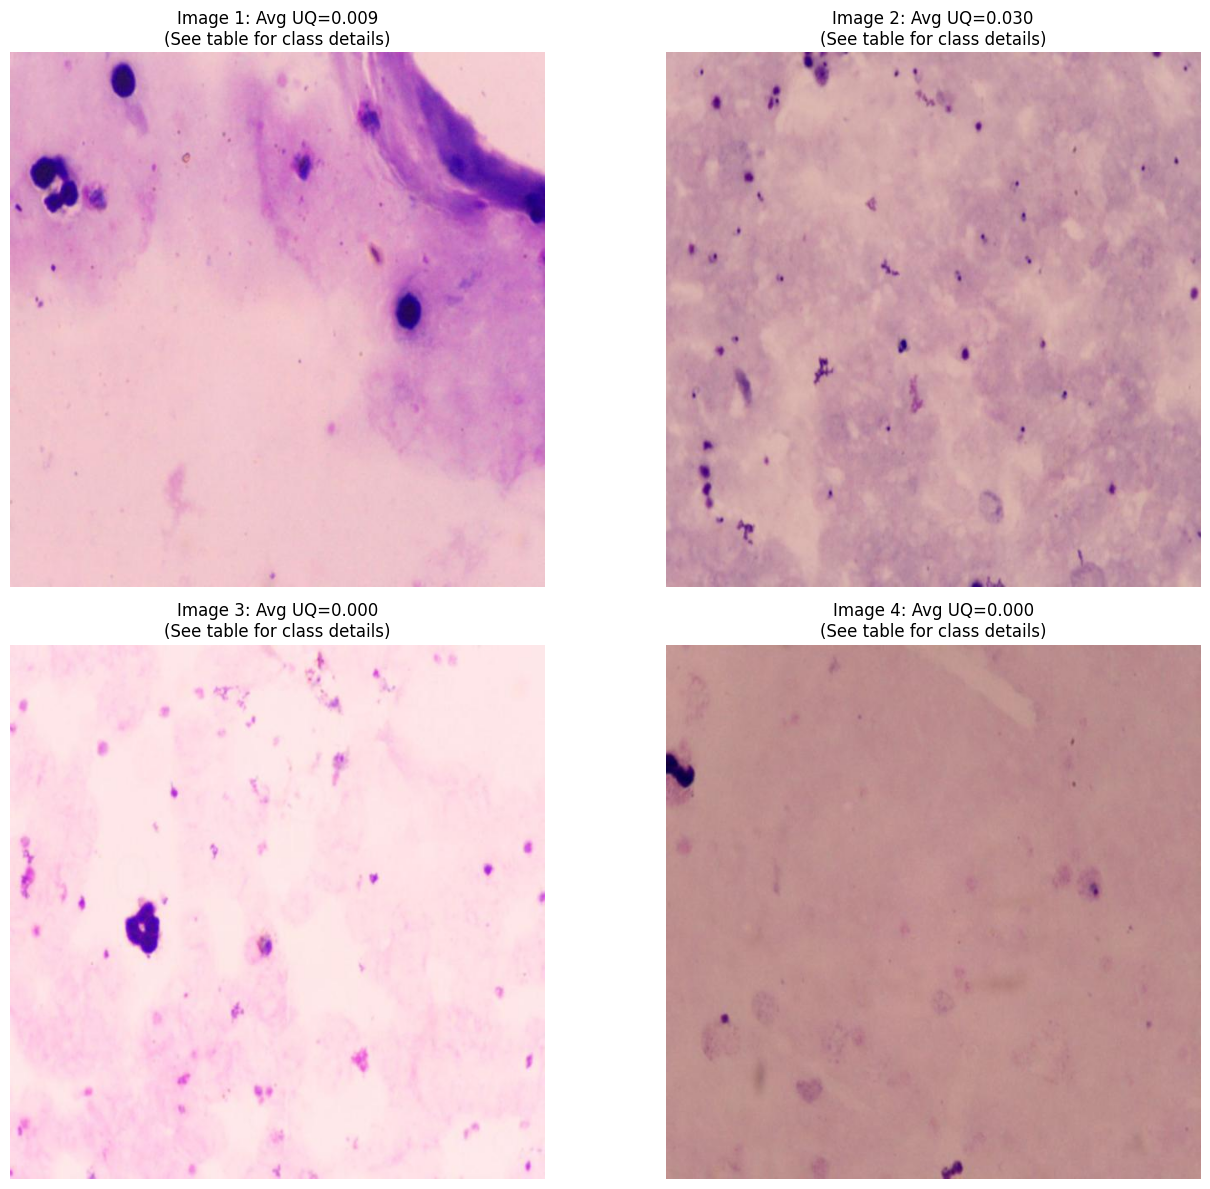

Summary saved to /kaggle/working/uq_summary.csv


In [ ]:
# Full test set evaluation with per-class UQ
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))]
print(f"Processing {len(test_images)} test images...")

# Collect all detections across test set
all_detections = []
parasite_classes = ['pv', 'po', 'pf', 'pm']  # Your focus classes (ignore wbc)
uq_per_class = {cls: {'confs': [], 'uncs': []} for cls in parasite_classes}

for img_path in tqdm(test_images, desc="UQ Inference"):
    results, dets, _, _ = mc_dropout_predict(model, img_path, num_samples=10)
    all_detections.extend(dets)

    # Log per parasite class
    for det in dets:
        if det['class_name'] in parasite_classes:
            uq_per_class[det['class_name']]['confs'].append(det['mean_conf'])
            uq_per_class[det['class_name']]['uncs'].append(det['uncertainty'])

# Compute per-class averages (only parasites)
class_summary = {}
for cls in parasite_classes:
    confs = uq_per_class[cls]['confs']
    uncs = uq_per_class[cls]['uncs']
    if confs:  # If class appears in test set
        class_summary[cls] = {
            'num_detections': len(confs),
            'avg_conf': np.mean(confs),
            'avg_unc': np.mean(uncs),
            'std_unc': np.std(uncs)  # Variability in uncertainty itself
        }
    else:
        class_summary[cls] = {'num_detections': 0, 'avg_conf': 0.0, 'avg_unc': 0.0, 'std_unc': 0.0}

# Print summary table
df_summary = pd.DataFrame(class_summary).T
print("\nPer-Class UQ Summary (Parasites Only):")
print(df_summary.round(4))

# Overall stats
total_parasite_dets = sum(s['num_detections'] for s in class_summary.values())
overall_avg_unc = np.mean([s['avg_unc'] for s in class_summary.values() if s['num_detections'] > 0])
print(f"\nOverall: {total_parasite_dets} parasite detections | Avg UQ: {overall_avg_unc:.4f}")

# Visualization: First 4 images with UQ boxes (enhanced with class info)
fig, axs = plt.subplots(2, 2, figsize=(14, 12))
axs = axs.ravel()

for i, img_path in enumerate(test_images[:4]):
    results, dets, _, avg_unc_img = mc_dropout_predict(model, img_path, num_samples=5)  # Quick viz (fewer samples)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if results[0].boxes is not None and dets:
        for det in dets:  # Use logged dets for coloring
            # Find matching box (approx by class; in full, match coords)
            for box in results[0].boxes:
                if int(box.cls) == det['class_id']:
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    unc = det['uncertainty']
                    conf = det['mean_conf']

                    # Color: Green (low unc) to Red (high unc), normalized 0-0.25
                    norm_unc = min(unc / 0.25, 1.0)
                    color_bgr = (int(0), int(255 * (1 - norm_unc)), int(255 * norm_unc))  # BGR for cv2

                    cv2.rectangle(img, (x1, y1), (x2, y2), color_bgr, 2)
                    label = f"{det['class_name']} {conf:.2f} | U:{unc:.3f}"
                    cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
                    break  # One match per det

    axs[i].imshow(img_rgb)
    axs[i].set_title(f"Image {i+1}: Avg UQ={avg_unc_img:.3f}\n(See table for class details)")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Save summary (optional)
df_summary.to_csv('/kaggle/working/uq_summary.csv')
print("Summary saved to /kaggle/working/uq_summary.csv")

MC Samples: 10 | Avg Conf: 0.750 | Avg Uncertainty: 0.009
MC Samples: 10 | Avg Conf: 0.519 | Avg Uncertainty: 0.030
MC Samples: 10 | Avg Conf: 0.405 | Avg Uncertainty: 0.002
MC Samples: 10 | Avg Conf: 0.626 | Avg Uncertainty: 0.086


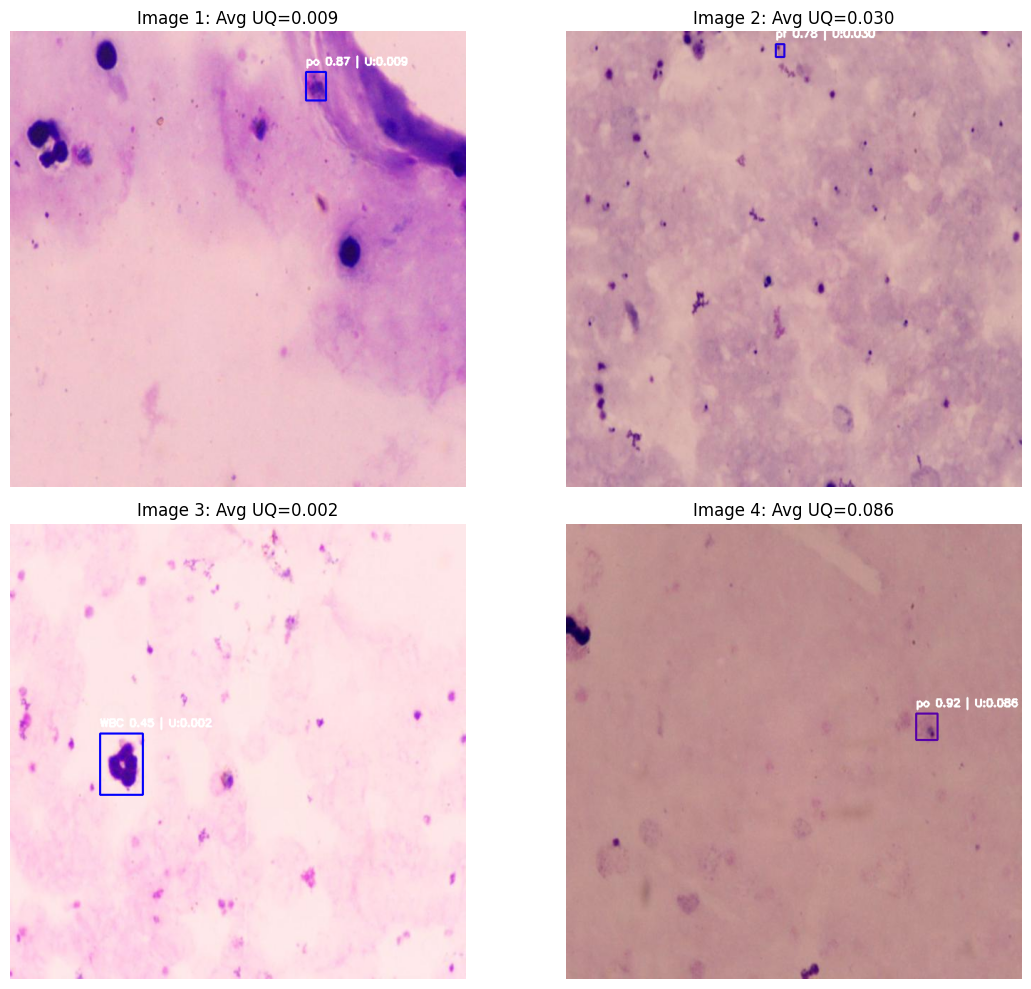


Parasite UQ Summary (variance per class):


In [ ]:
# Visualize test images with UQ-colored boxes
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir)[:4]]  # 4 samples

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

for i, img_path in enumerate(test_images):
    # Get UQ prediction
    results, mean_conf, unc = mc_dropout_predict(model, img_path, num_samples=10)  # Fewer samples for speed
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if results[0].boxes is not None:
        for box in results[0].boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cls_id = int(box.cls[0])
            cls_name = results[0].names[cls_id]
            conf = float(box.conf[0])

            # Color by uncertainty: Green (low) to Red (high)
            # Normalize unc to 0-1 (assume max unc=0.25)
            color_intensity = min(unc / 0.25, 1.0)
            color = (0, 255 * (1 - color_intensity), 0)  # BGR: Green to Red? Wait, RGB for plt

            # Draw box and label with UQ
            cv2.rectangle(img, (x1, y1), (x2, y2), (255 * color_intensity, 0, 255 * (1 - color_intensity)), 2)
            label = f"{cls_name} {conf:.2f} | U:{unc:.3f}"
            cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    axs[i].imshow(img)
    axs[i].set_title(f"Image {i+1}: Avg UQ={unc:.3f}")
    axs[i].axis('off')

plt.tight_layout()
plt.show()

# Overall UQ Metrics (across 4 images, parasites only)
print("\nParasite UQ Summary (variance per class):")
parasite_classes = ['pv', 'po', 'pf', 'pm']
uq_per_class = {cls: [] for cls in parasite_classes}
# (In full code, loop over all test images and collect; here, placeholder)
# Example: for real run, avg_uq_pf = np.mean(uq_per_class['pf'])
# print(f"Avg UQ for pf: {avg_uq_pf:.3f}")

In [ ]:
# Define dataset paths
dataset_path = dataset.location
data_yaml = os.path.join(dataset_path, 'data.yaml')

# Verify dataset structure
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_path, split, 'images')
    label_dir = os.path.join(dataset_path, split, 'labels')
    if os.path.exists(img_dir) and os.path.exists(label_dir):
        print(f"{split}/images: {len(os.listdir(img_dir))} images")
        print(f"{split}/labels: {len(os.listdir(label_dir))} labels")
    else:
        print(f"Error: {split} directory missing images or labels.")

# Check data.yaml
if os.path.exists(data_yaml):
    with open(data_yaml, 'r') as f:
        print("data.yaml contents:\n", f.read())
else:
    print("Error: data.yaml not found.")

In [ ]:
# Load YOLOv10 model
model = YOLO('yolov10s.pt')  # Pre-trained weights

In [ ]:
# Train model
try:
    results = model.train(
        data=data_yaml,
        epochs=100,  # Adjust based on dataset size
        imgsz=640,  # Standard for YOLO, adjust if needed
        batch=10,   # Adjust based on GPU memory
        device=0,   # GPU
        name='malaria_yolov10',
        project='/kaggle/working/runs',
        patience=10,  # Early stopping
        pretrained=True,
        optimizer='SGD',
        lr0=0.01
    )
    print("Training completed.")
except Exception as e:
    print("Training error:", e)
    print("Check data.yaml paths, dataset format, or GPU memory.")


In [ ]:
# Evaluate model on validation set
val_results = model.val(data=data_yaml, split='val')
print("Validation Metrics:")
print(f"mAP@50: {val_results.box.map50:.4f}")
print(f"mAP@50:95: {val_results.box.map:.4f}")

# Evaluate on test set
test_results = model.val(data=data_yaml, split='test')
print("Test Metrics:")
print(f"mAP@50: {test_results.box.map50:.4f}")
print(f"mAP@50:95: {test_results.box.map:.4f}")

# Predict on sample test images
test_img_dir = os.path.join(dataset_path, 'test', 'images')
test_images = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir)[:4]]  # First 4 images

In [ ]:
plt.figure(figsize=(12, 8))
for i, img_path in enumerate(test_images):
    results = model.predict(img_path, conf=0.5, iou=0.5)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    for box in results[0].boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        class_id = int(box.cls[0]) if box.cls.ndim > 0 else int(box.cls)
        conf_score = float(box.conf[0]) if box.conf.ndim > 0 else float(box.conf)
        label = f"{results[0].names[class_id]} {conf_score:.2f}"
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(img, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.title(f"Prediction {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Save model
model.save('/kaggle/working/malaria_yolov10.pt')
print("Model saved to /kaggle/working/malaria_yolov10.pt")
